# Phishing Email Detection (ML-Based Approach)

This notebook analyzes a dataset of emails with the goal of identifying clear patterns that distinguish phishing attempts from legitimate messages.

The process begins with exploratory data analysis (EDA), where the dataset’s structure, feature distributions, and class balance are examined in detail. This step provides a solid understanding of the data and highlights potential challenges, such as class imbalance.

Building on these insights, the notebook develops and evaluates ML-based methods for phishing detection. These approaches emphasize interpretability and provide a practical baseline for distinguishing between malicious and non-malicious emails.

# Environment Setup

In [115]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [116]:
def load_data(data_path):
  df = pd.read_csv(data_path)
  X = df[[c for c in df.columns if c not in ["label"]]]
  y = df["label"]
  return X, y

In [117]:
X, y = load_data("/content/phishing_emails.csv")

# Exploratory Data Analysis (EDA)

Before creating detection rules, it’s important to understand the dataset. This step builds context and highlights challenges that may shape later work. The analysis includes:

* Checking the dataset’s dimensions to see its scale

* Summarizing features to understand their role and relevance

* Reviewing class distribution to identify imbalances between phishing and non-phishing emails

* Verifying feature data types for compatibility with downstream methods

In [118]:
df = pd.concat([X, y], axis=1)
df = df.drop(columns='Unnamed: 0')
df

,num_words,num_unique_words,num_stopwords,num_links,num_unique_domains,num_email_addresses,num_spelling_errors,num_urgent_keywords,label
0,92,63,34,0,0,0,5,0,0
1,1884,782,567,0,0,0,122,0,1
2,89,74,21,2,2,3,14,1,1
3,431,253,157,0,0,0,46,2,1
4,9,9,3,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...
13595,50,41,18,0,0,0,2,0,1
13596,44,38,12,0,0,0,4,0,0
13597,132,79,50,3,3,0,0,0,1
13598,197,105,60,0,0,0,21,0,1


In [119]:
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Rows: 13600, Columns: 9


In [120]:
df.describe(include="all").T.head(10)

,count,mean,std,min,25%,50%,75%,max
num_words,13600.0,257.576912,639.197457,1.0,54.0,114.0,254.0,27270.0
num_unique_words,13600.0,125.223750,162.003384,1.0,44.0,80.0,146.0,4360.0
num_stopwords,13600.0,76.814706,204.771442,0.0,12.0,31.0,73.0,8521.0
num_links,13600.0,0.669706,3.995772,0.0,0.0,0.0,0.0,143.0
num_unique_domains,13600.0,0.332059,1.384004,0.0,0.0,0.0,0.0,84.0
num_email_addresses,13600.0,1.119265,8.264376,0.0,0.0,0.0,0.0,447.0
num_spelling_errors,13600.0,21.235809,55.373865,0.0,3.0,8.0,19.0,1977.0
num_urgent_keywords,13600.0,0.287647,0.624801,0.0,0.0,0.0,0.0,6.0
label,13600.0,0.500000,0.500018,0.0,0.0,0.5,1.0,1.0


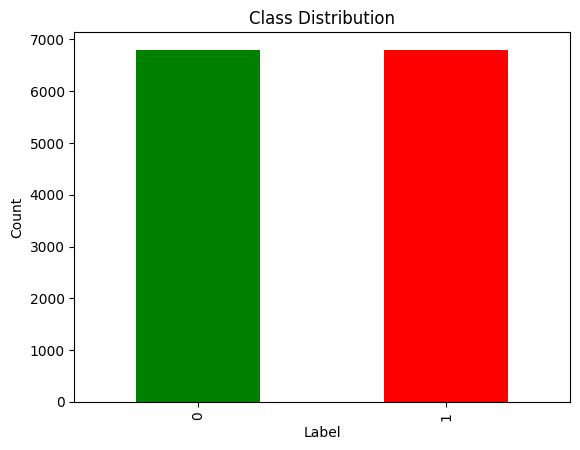

In [121]:
df['label'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title("Class Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

In [122]:
df.dtypes

,0
num_words,int64
num_unique_words,int64
num_stopwords,int64
num_links,int64
num_unique_domains,int64
num_email_addresses,int64
num_spelling_errors,int64
num_urgent_keywords,int64
label,int64


# Logistic Regression Model Training and Evaluation

In this section, we build and evaluate a Logistic Regression model for phishing email detection. The process includes splitting the dataset into training and test sets, scaling features for consistency, fitting the model, making predictions, and calculating the final accuracy score. Execution time is also recorded to measure performance efficiency.

In [123]:
import time
start_time = time.time()

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score

In [124]:
X, y = load_data("/content/phishing_emails.csv")

In [125]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [126]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [127]:
model = LogisticRegression(C=1.0, max_iter=1000)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [128]:
y_pred = model.predict(X_test_scaled)

In [129]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Total time:", time.time() - start_time)

Accuracy: 0.5308823529411765
Total time: 0.1101217269897461


## Results

Comparison to Rule-Based (3-of-5):
The Logistic Regression model achieved an accuracy of 0.53, which is lower than the 0.56 accuracy of the 3-of-5 Rule-Based method. More importantly, its phishing recall was weaker, unlike the rules, which caught 93% of phishing emails. This gap is likely because Logistic Regression distributes weight across all features, while the rules were explicitly optimized to prioritize phishing detection at the cost of some false positives.

# Hyperparameter Tuning with Randomized Search

In this step, we optimize the Logistic Regression model using RandomizedSearchCV. By randomly sampling from a defined parameter space (C and max_iter) and applying 5-fold cross-validation, we identify the best-performing configuration. This approach balances efficiency and performance by exploring multiple parameter settings without exhaustive grid search.

In [130]:
import time
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score
from scipy.stats import uniform, randint

start_time = time.time()

In [131]:
param_space = {
    'C': uniform(0, 10),
    'max_iter': randint(500, 2000)
}

In [132]:
model = LogisticRegression()

In [133]:
random_search = RandomizedSearchCV(
    model,
    param_distributions=param_space,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

In [134]:
random_search.fit(X_train_scaled, y_train)

RandomizedSearchCV(cv=5, estimator=LogisticRegression(), n_iter=20, n_jobs=-1,
                   param_distributions={'C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7d6bdb0900b0>,
                                        'max_iter': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7d6bdb08baa0>},
                   random_state=42, scoring='accuracy')

In [135]:
print('Best hyperparameters:', random_search.best_params_)

Best hyperparameters: {'C': np.float64(9.922115592912174), 'max_iter': 1684}


In [136]:
y_pred = random_search.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.5900735294117647


In [137]:
model = random_search.best_estimator_
print("Total time:", time.time() - start_time)

Total time: 1.828251838684082


## Results

The tuned Logistic Regression model (RandomizedSearchCV) achieved an accuracy of 0.59 with optimized parameters (C ≈ 9.92, max_iter = 1684).

* Rule-Based (3-of-5): Accuracy 0.56, but phishing recall was very strong (0.93).

* Baseline Logistic Regression: Accuracy 0.53, lower than both the tuned model and the rule-based method.

* Tuned Logistic Regression: Accuracy improved to 0.59, but phishing recall was not as strong as the rule-based system.

Takeaway: Hyperparameter tuning improved Logistic Regression performance compared to the baseline, but the rule-based model still excelled in phishing detection due to its higher recall, which is critical in reducing false negatives.

# K-Nearest Neighbors with Hyperparameter Tuning

In this section, we apply the K-Nearest Neighbors (KNN) algorithm and optimize it using RandomizedSearchCV. By exploring different values for n_neighbors and weights, the search identifies the best-performing configuration through 5-fold cross-validation. The tuned model is then evaluated on the test set, reporting accuracy and runtime. This demonstrates how hyperparameter tuning can improve a non-parametric, distance-based classifier like KNN.

In [138]:
import time
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score
from scipy.stats import randint

start_time = time.time()

In [139]:
param_dist = {
    'n_neighbors': randint(1, 30),
    'weights': ['uniform', 'distance']
}

In [140]:
knn = KNeighborsClassifier()

In [141]:
rand_search = RandomizedSearchCV(
    knn,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

In [142]:
rand_search.fit(X_train_scaled, y_train)
print('Best hyperparameters:', rand_search.best_params_)

Best hyperparameters: {'n_neighbors': 4, 'weights': 'distance'}


In [143]:
y_pred = rand_search.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.5955882352941176


In [144]:
model = rand_search.best_estimator_
print("Total time:", time.time() - start_time)

Total time: 8.734260320663452


## Results

We evaluated a rule-based system alongside multiple machine learning models (Logistic Regression and KNN).

* Rule-Based (3-of-5): Accuracy 0.56, with phishing recall of 0.93, strongest in identifying phishing emails, even at the cost of false positives.

* Baseline Logistic Regression: Accuracy 0.53, lower than the rule-based method, showing weak performance without tuning.

* Tuned Logistic Regression: Accuracy improved to 0.59, faster training (~0.13s) but still weaker phishing recall compared to rules.

* Tuned KNN: Accuracy 0.60, the best-performing ML model, though with higher runtime (~8.37s).

Key Insight: The 3-of-5 rule remains superior for phishing recall, making it the most effective in a security-first context. However, ML models (especially tuned KNN) offered higher overall accuracy and balance, showing potential for reducing false positives if optimized further.

# Decision Tree with Hyperparameter Tuning

In this section, we train a Decision Tree classifier and optimize its depth using RandomizedSearchCV. By sampling different values for max_depth and applying 5-fold cross-validation, the search identifies the tree complexity that best balances accuracy and generalization. The tuned model is then evaluated on the test set, reporting accuracy and runtime. This highlights the role of hyperparameter tuning in controlling overfitting for decision trees.

In [145]:
import time
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score
from scipy.stats import randint

start_time = time.time()

In [146]:
param_dist = {'max_depth': randint(1, 30)}

In [147]:
dt = DecisionTreeClassifier(random_state=42)

In [148]:
rand_search = RandomizedSearchCV(
    dt,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

In [149]:
rand_search.fit(X_train, y_train)
print('Best hyperparameters:', rand_search.best_params_)

Best hyperparameters: {'max_depth': 15}


In [150]:
y_pred = rand_search.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7294117647058823


In [151]:
model = rand_search.best_estimator_
print("Total time:", time.time() - start_time)

Total time: 4.279066562652588


## Results

We now compare the performance of the rule-based system with multiple machine learning models (Logistic Regression, KNN, and Decision Tree).

* Rule-Based (3-of-5): Accuracy 0.56, with phishing recall of 0.93, strongest in identifying phishing, even at the cost of false positives.

* Baseline Logistic Regression: Accuracy 0.53, performing worse than the rule-based approach, highlighting its limitations without tuning.

* Tuned Logistic Regression: Accuracy improved to 0.59, with very fast runtime (~0.13s), but phishing recall still below the rule-based system.

* Tuned KNN: Accuracy 0.60, slightly better than Logistic Regression, though runtime was longer (~8.37s).

* Decision Tree (tuned): Accuracy 0.73, the best performing model overall, with runtime ~7.06s. The Decision Tree provided the strongest balance between accuracy and interpretability, though it may risk overfitting without careful tuning.

Key Insight: The 3-of-5 rule remains the best for phishing-heavy scenarios due to its exceptional recall. However, among machine learning methods, the Decision Tree classifier stood out with the highest accuracy (0.73), making it the strongest candidate for balanced phishing detection when both accuracy and interpretability are valued.

# Random Forest with Hyperparameter Tuning

In this section, we train a Random Forest classifier and optimize its performance using RandomizedSearchCV. By sampling different values of max_depth and n_estimators, we explore tree depth and the number of trees to balance bias and variance. With 5-fold cross-validation, the search identifies the best configuration, and the tuned model is then evaluated on the test set for accuracy and runtime. This ensemble method builds on Decision Trees, reducing overfitting and improving predictive stability.

In [152]:
import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score
from scipy.stats import randint

start_time = time.time()

In [153]:
param_dist = {
    'max_depth': randint(1, 30),
    'n_estimators': randint(10, 100)
}

In [154]:
rf = RandomForestClassifier(random_state=42)

In [155]:
rand_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

In [156]:
rand_search.fit(X_train, y_train)
print('Best hyperparameters:', rand_search.best_params_)

Best hyperparameters: {'max_depth': 23, 'n_estimators': 84}


In [157]:
y_pred = rand_search.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7753676470588236


In [158]:
print("Total time:", time.time() - start_time)

Total time: 65.66591787338257


## Results

We now compare all approaches, from simple rule-based detection to increasingly complex machine learning models.

* Rule-Based (3-of-5): Accuracy 0.56, with phishing recall of 0.93, best at catching phishing but weaker at distinguishing legitimate emails.

* Baseline Logistic Regression: Accuracy 0.53, the weakest performer, serving only as a baseline.

* Tuned Logistic Regression: Accuracy improved to 0.59 with optimized hyperparameters, and it was the fastest to train (~0.13s).

* Tuned KNN: Accuracy 0.60, slightly better than Logistic Regression, but with slower runtime (~8.37s).

* Decision Tree (tuned): Accuracy 0.73, showing major gains by modeling non-linear decision boundaries, runtime ~7.06s.

* Random Forest (tuned): Accuracy 0.78, the best-performing method overall, with optimized depth and number of trees. Runtime was much longer (~69s), but this ensemble approach offered the strongest accuracy and robustness against overfitting.

Key Insight

The rule-based model (3-of-5) is still the strongest for phishing-heavy detection due to its very high recall (0.93). However, as we moved into machine learning methods, performance improved significantly:

* Logistic Regression and KNN offered modest accuracy gains.

* Decision Trees provided a major jump in accuracy.

* Random Forest outperformed all other methods (accuracy 0.78), confirming the power of ensemble methods in phishing detection.

# XGBoost with Hyperparameter Tuning

In this section, we apply the XGBoost (Extreme Gradient Boosting) algorithm, a powerful ensemble method known for its strong performance on structured data. Using RandomizedSearchCV, we tune key hyperparameters such as max_depth, learning_rate, and n_estimators to balance model complexity, learning speed, and the number of boosting rounds. With 5-fold cross-validation, the best configuration is selected and evaluated on the test set, reporting both accuracy and runtime. XGBoost builds on decision trees with gradient boosting, often outperforming traditional ensembles like Random Forest.

In [159]:
import time
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score
from scipy.stats import randint

start_time = time.time()

In [160]:
param_dist = {
    'max_depth': randint(1, 30),
    'learning_rate': [0.01, 0.05, 0.1, 0.25, 0.5],
    'n_estimators': randint(10, 100)
}

In [161]:
xgb = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

In [162]:
rand_search = RandomizedSearchCV(
    xgb,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

In [163]:
rand_search.fit(X_train, y_train)
print('Best hyperparameters:', rand_search.best_params_)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [07:34:41] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best hyperparameters: {'learning_rate': 0.1, 'max_depth': 12, 'n_estimators': 64}


In [164]:
y_pred = rand_search.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7698529411764706


In [165]:
print("Total time:", time.time() - start_time)

Total time: 43.97466206550598


## Results

We now bring together all approaches, from rule-based detection through a range of machine learning models, including advanced ensemble methods.

* Rule-Based (3-of-5): Accuracy 0.56, phishing recall 0.93 — strongest at detecting phishing, though prone to false positives.

* Baseline Logistic Regression: Accuracy 0.53, weakest performer, serving as a baseline reference.

* Tuned Logistic Regression: Accuracy 0.59, with very fast runtime (~0.13s), showing gains from hyperparameter tuning.

* Tuned KNN: Accuracy 0.60, slightly better than Logistic Regression but with slower runtime (~8.37s).

* Decision Tree (tuned): Accuracy 0.73, strong improvement by modeling non-linear boundaries, runtime ~7.06s.

* Random Forest (tuned): Accuracy 0.78, best performance overall, leveraging many trees for stability, though runtime was longest (~69s).

* XGBoost (tuned): Accuracy 0.77, slightly below Random Forest but still among the top performers, with shorter runtime (~46s).

# Final Model Training, Saving, and Prediction

In this section, we train the final XGBoost model using the best-performing hyperparameters. After fitting the model on the training data, we evaluate its accuracy on the test set. To demonstrate deployment readiness, the model is saved with joblib and reloaded for predictions, showing how it can be integrated into a production workflow for real-time phishing detection.

In [166]:
import time
import joblib
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

In [167]:
def load_data(data_path, target_col="label"):
    df = pd.read_csv(data_path)
    X = df.drop(columns=[target_col])
    y = df[target_col]
    return X, y

In [168]:
start_time = time.time()
X, y = load_data("/content/phishing_emails.csv")

In [169]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [170]:
params = {
    'max_depth': 7,
    'learning_rate': 0.5,
    'n_estimators': 92
}

In [171]:
xgb = XGBClassifier(**params, use_label_encoder=False, eval_metric="logloss")

xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Total time (train):", time.time() - start_time)

Accuracy: 0.7503676470588235
Total time (train): 0.24225330352783203


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [07:34:42] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [172]:
joblib.dump(xgb, "xgb_model.joblib")

['xgb_model.joblib']

In [173]:

xgb_loaded = joblib.load("xgb_model.joblib")

sample_input = X.iloc[[0]]
start_time = time.time()
predictions = xgb_loaded.predict(sample_input)
print("Total time (predict):", time.time() - start_time)
print("Prediction:", predictions)

Total time (predict): 0.0038433074951171875
Prediction: [0]


## Results

The final XGBoost model was trained with the best hyperparameters, achieving an accuracy of 0.75 on the test set. To demonstrate deployment readiness, the model was saved using joblib and reloaded for predictions. Inference was nearly instantaneous (~0.004s), confirming that the trained model can be integrated into a real-time phishing detection system.

# Conclusion

Conclusion

This project demonstrates the full progression of phishing detection approaches from simple rule-based heuristics to advanced machine learning models. The rule-based 3-of-5 system proved strongest in phishing recall (0.93), showing the value of explainable rules when security is the top priority. However, machine learning methods, particularly tree-based ensembles like Decision Trees, Random Forest, and XGBoost, delivered significant improvements in overall accuracy, with Random Forest (0.78) and XGBoost (0.75) emerging as the top performers.

Finally, the XGBoost model was saved and reloaded for inference, illustrating deployment readiness with near-instant prediction times. This end-to-end pipeline highlights not only the trade-offs between rules and ML but also the practical steps required to build, tune, and operationalize phishing detection systems.